Step 1 :  Dataset Processing 

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("C:/Users/M/Downloads/heart_project/heart.csv")
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1.0,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0.0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1.0,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1.0,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1.0,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1.0,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0.0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0.0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0.0,159,0,0.0,2,0,2,1


In [4]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     1
thalach     0
exang       0
oldpeak     2
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:
data.dropna(inplace=True)
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
scaler = MinMaxScaler()
numerical_features = data.select_dtypes(include=['int64', 'float64']).columns
#choose numerical features to scale
data[numerical_features] = scaler.fit_transform(data[numerical_features])


In [7]:
# One-Hot Encoding
data = pd.get_dummies(data, drop_first=True)
print(data.head())

        age  sex   cp  trestbps      chol  fbs  restecg   thalach  exang  \
0  0.479167  1.0  0.0  0.292453  0.196347  0.0      0.5  0.740458    0.0   
1  0.500000  1.0  0.0  0.433962  0.175799  1.0      0.0  0.641221    1.0   
2  0.854167  1.0  0.0  0.481132  0.109589  0.0      0.5  0.412214    1.0   
3  0.666667  1.0  0.0  0.509434  0.175799  0.0      0.5  0.687023    0.0   
4  0.687500  0.0  0.0  0.415094  0.383562  1.0      0.5  0.267176    0.0   

    oldpeak  slope    ca      thal  target  
0  0.161290    1.0  0.50  1.000000     0.0  
1  0.500000    0.0  0.00  1.000000     0.0  
2  0.419355    0.0  0.00  1.000000     0.0  
3  0.000000    1.0  0.25  1.000000     0.0  
4  0.306452    0.5  0.75  0.666667     0.0  


In [8]:
# Correlation with target
correlation = data.corr()
target_corr = correlation["target"].sort_values(ascending=False)
print(target_corr)

target      1.000000
cp          0.438679
thalach     0.423188
slope       0.345566
restecg     0.133878
fbs        -0.038965
chol       -0.099351
trestbps   -0.139704
age        -0.229106
sex        -0.279398
thal       -0.338207
ca         -0.380889
oldpeak    -0.437571
exang      -0.437950
Name: target, dtype: float64


In [9]:
selected_features = target_corr[abs(target_corr) > 0.2].index
print(selected_features)

Index(['target', 'cp', 'thalach', 'slope', 'age', 'sex', 'thal', 'ca',
       'oldpeak', 'exang'],
      dtype='object')


In [10]:
data = data[selected_features]
data


,target,cp,thalach,slope,age,sex,thal,ca,oldpeak,exang
0,0.0,0.000000,0.740458,1.0,0.479167,1.0,1.000000,0.50,0.161290,0.0
1,0.0,0.000000,0.641221,0.0,0.500000,1.0,1.000000,0.00,0.500000,1.0
2,0.0,0.000000,0.412214,0.0,0.854167,1.0,1.000000,0.00,0.419355,1.0
3,0.0,0.000000,0.687023,1.0,0.666667,1.0,1.000000,0.25,0.000000,0.0
4,0.0,0.000000,0.267176,0.5,0.687500,0.0,0.666667,0.75,0.306452,0.0
...,...,...,...,...,...,...,...,...,...,...
1020,1.0,0.333333,0.709924,1.0,0.625000,1.0,0.666667,0.00,0.000000,1.0
1021,0.0,0.000000,0.534351,0.5,0.645833,1.0,1.000000,0.25,0.451613,1.0
1022,0.0,0.000000,0.358779,0.5,0.375000,1.0,0.666667,0.25,0.161290,1.0
1023,1.0,0.000000,0.671756,1.0,0.437500,0.0,0.666667,0.00,0.000000,0.0


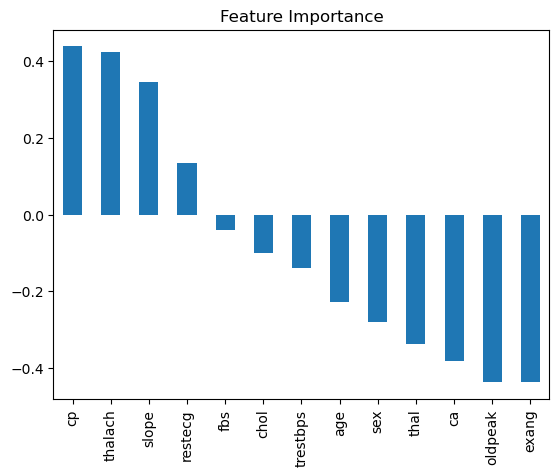

In [11]:
target_corr.drop("target").plot(kind='bar')
plt.title("Feature Importance")
plt.show()

In [12]:
data.to_csv("cleaned_data.csv", index=False)

Step 2: Data Visualization 

In [13]:
data.describe()

,target,cp,thalach,slope,age,sex,thal,ca,oldpeak,exang
count,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000
mean,0.513699,0.314090,0.596368,0.693249,0.529660,0.694716,0.775277,0.188356,0.172669,0.336595
std,0.500057,0.342765,0.175867,0.309154,0.189225,0.460753,0.206673,0.257819,0.189615,0.472776
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.465649,0.500000,0.395833,0.000000,0.666667,0.000000,0.000000,0.000000
50%,1.000000,0.333333,0.618321,0.500000,0.562500,1.000000,0.666667,0.000000,0.129032,0.000000
75%,1.000000,0.666667,0.725191,1.000000,0.666667,1.000000,1.000000,0.250000,0.290323,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


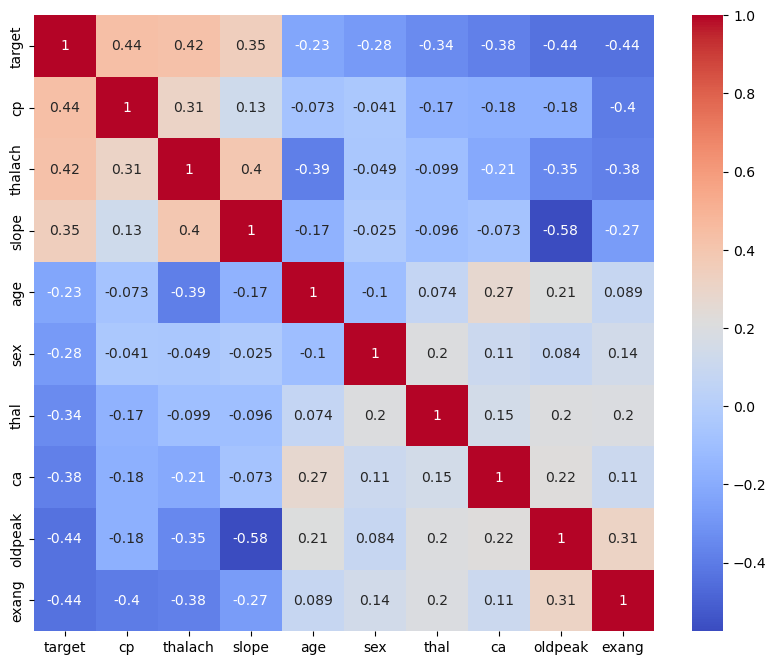

In [14]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

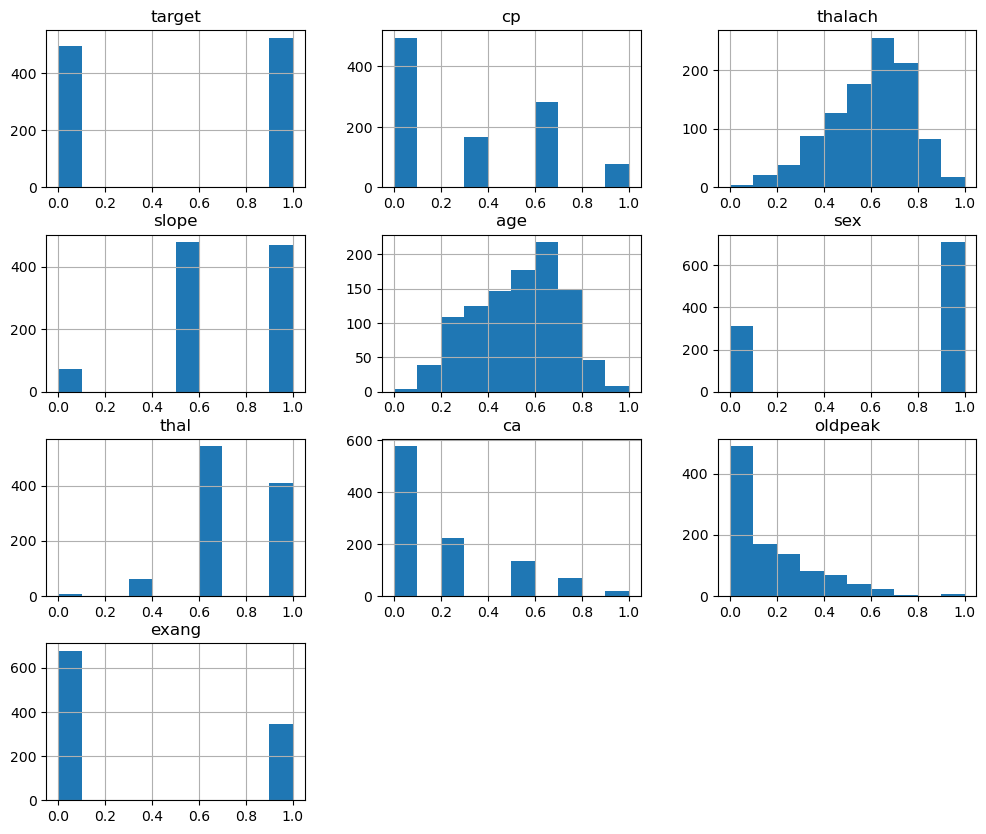

In [15]:
# Histograms
data.hist(figsize=(12,10))
plt.show()


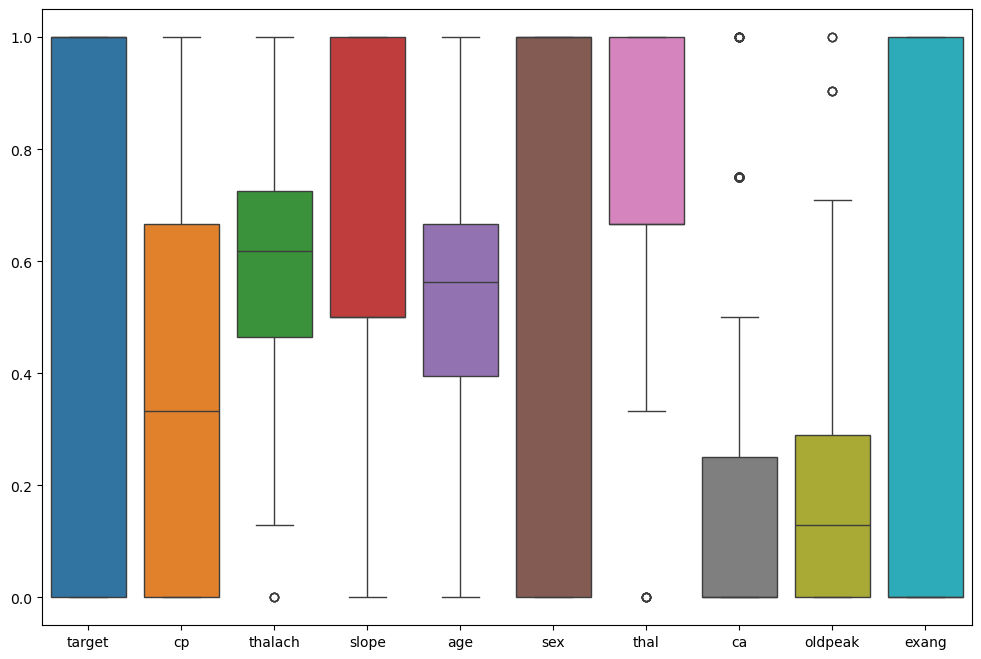

In [16]:
# Boxplots
plt.figure(figsize=(12,8))
sns.boxplot(data=data)
plt.show()